# OptiWMS — Evaluation Evidence

Every number below is computed live from the operational database at run time. Nothing is
hard-coded, so any cell can be re-run on request.

**What this notebook establishes**

| § | Question it answers |
|---|---|
| 1 | What model is promoted, and is the forecast genuinely multi-horizon? |
| 2 | How accurate is it, and are the prediction intervals calibrated? |
| 3 | What is the forecast origin, and how are in-sample and out-of-sample separated? |
| 4 | Do min/max and slotting consume past periods? (they do not — proven by query) |
| 5 | Is the Monte Carlo real, and is it reproducible? |
| 6 | What horizon does each decision layer plan over? |
| 7 | What is synthetic in this database, and is it declared? |

Run **Cell → Run All**. Read-only throughout: no INSERT, UPDATE or DELETE is issued.

In [1]:
import psycopg2, pandas as pd, numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)

DSN = dict(host="localhost", port=5434, dbname="optiwms", user="optiwms", password="optiwms")

def q(sql, **params):
    """Run a read-only query and return a DataFrame."""
    with psycopg2.connect(**DSN) as conn:
        return pd.read_sql(sql, conn, params=params or None)

# ── AS-OF DATE ────────────────────────────────────────────────────────────────
# Every window below is evaluated against this date rather than an implicit
# DATE %(as_of)s, so the run is reproducible and the date is stated on the page.
# Leave as None to use the database's own date; pin it to re-create an earlier run.
AS_OF = None            # e.g. "2026-08-17"

AS_OF = AS_OF or str(q("SELECT CURRENT_DATE AS d").d.iloc[0])

print(f"Connected to optiwms")
print(f"Evidence evaluated as of : {AS_OF}")
print(f"Database date            : {q('SELECT CURRENT_DATE AS d').d.iloc[0]}")


Connected to optiwms
Evidence evaluated as of : 2026-08-17
Database date            : 2026-08-17


/var/folders/r3/4mc1fwy55g19lwlpxnq0wwnm0000gn/T/ipykernel_8463/3153288650.py:12: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conn, params=params or None)


---
## 1 · The promoted model, and multi-horizon structure

The demand forecast is an **Extra Trees** global causal model producing recursive multi-step
forecasts with P10/P50/P90 quantiles.

In [2]:
q("""
SELECT model_name, training_source, method,
       count(*) AS rows, count(DISTINCT material_id) AS skus,
       min(forecast_period) AS first_period, max(forecast_period) AS last_period,
       min(created_at)::date AS generated_on
FROM forecast_results
GROUP BY 1,2,3 ORDER BY rows DESC
""")

/var/folders/r3/4mc1fwy55g19lwlpxnq0wwnm0000gn/T/ipykernel_8463/3153288650.py:12: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conn, params=params or None)


,model_name,training_source,method,rows,skus,first_period,last_period,generated_on
0,EXTRA_TREES,PROJECT_OPERATIONAL_BASELINE_V1,GLOBAL_CAUSAL,9240,770,2026-01-01,2026-12-01,2026-07-14
1,V7_RM_PM_DIRECT,None,lightgbm_global_rm_pm,3456,288,2026-02-01,2027-01-01,2026-07-09
2,RM_GROSS_REQ_V6,None,canonical_v6,2004,167,2025-08-01,2026-12-01,2026-06-26
3,PROJECT_OPS_EXTRA_TREES_CAUSAL,project_ops_v8,extra_trees_causal_recursive,1440,120,2026-01-01,2026-12-01,2026-08-13
4,EXTRA_TREES_RESPONSIVE,PROJECT_OPERATIONAL_BASELINE_V3,GLOBAL_CAUSAL,1152,96,2026-01-01,2026-12-01,2026-07-19
5,EXTRA_TREES,PROJECT_OPERATIONAL_BASELINE_V2,GLOBAL_CAUSAL,1152,96,2026-01-01,2026-12-01,2026-07-14
6,EXTRA_TREES_DAMPED_TREND,PROJECT_OPERATIONAL_BASELINE_V3,GLOBAL_CAUSAL,1152,96,2026-01-01,2026-12-01,2026-07-19
7,CANONICAL_BASELINE_V6,None,canonical_history_baseline,642,107,2026-07-01,2026-12-01,2026-06-26


### Is it multi-horizon?

Yes — and this is the evidence. Each SKU carries a **separate forecast per horizon step h = 1…12**,
not one aggregated line. The count is identical at every h because every SKU is forecast at every
step.

In [3]:
h = q("""
SELECT horizon, count(*) AS forecast_rows, count(DISTINCT material_id) AS skus
FROM forecast_results WHERE model_name = 'EXTRA_TREES'
GROUP BY 1 ORDER BY 1
""")
display(h)
print(f"Horizon steps stored: {h.horizon.min()} to {h.horizon.max()}   "
      f"({h.skus.iloc[0]} SKUs x {len(h)} horizons = {h.forecast_rows.sum():,} rows)")

/var/folders/r3/4mc1fwy55g19lwlpxnq0wwnm0000gn/T/ipykernel_8463/3153288650.py:12: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conn, params=params or None)


,horizon,forecast_rows,skus
0,1,866,866
1,2,866,866
2,3,866,866
3,4,866,866
4,5,866,866
5,6,866,866
6,7,866,866
7,8,866,866
8,9,866,866
9,10,866,866


Horizon steps stored: 1 to 12   (866 SKUs x 12 horizons = 10,392 rows)


**On the UI:** the dashboard slider filters *which* horizons are plotted (`horizon <= selected`)
and aggregates them onto one line. The per-horizon detail exists in the data — it is simply not
fanned out visually. The cell above is the honest way to show multi-horizon structure; the
next cell plots the fan the UI does not draw.

/var/folders/r3/4mc1fwy55g19lwlpxnq0wwnm0000gn/T/ipykernel_8463/3153288650.py:12: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conn, params=params or None)


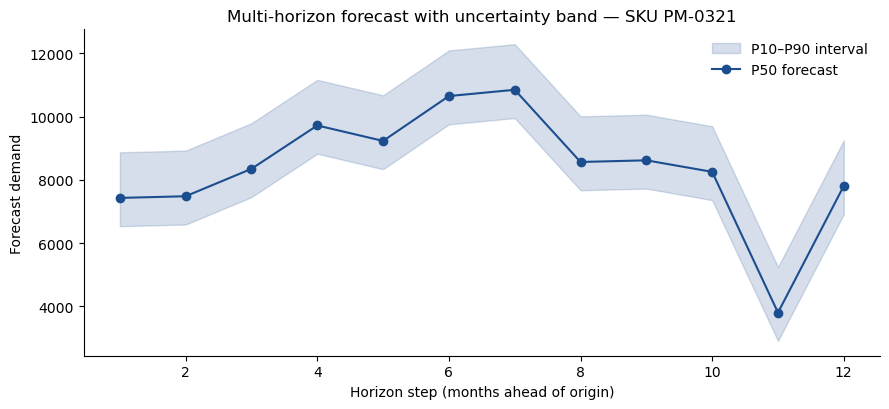

In [4]:
# One SKU, all 12 horizon steps, with the P10-P90 band the UI collapses.
sku = q("""
SELECT f.horizon, f.forecast_p10, f.forecast_p50, f.forecast_p90, m.material_code
FROM forecast_results f JOIN materials m ON m.id = f.material_id
WHERE f.model_name = 'EXTRA_TREES'
  AND f.material_id = (SELECT material_id FROM forecast_results
                       WHERE model_name='EXTRA_TREES' AND forecast_p50 > 0
                       ORDER BY forecast_p50 DESC LIMIT 1)
ORDER BY f.horizon
""")

fig, ax = plt.subplots(figsize=(9, 4.2))
ax.fill_between(sku.horizon, sku.forecast_p10.astype(float), sku.forecast_p90.astype(float),
                alpha=0.18, color="#1B4D8F", label="P10–P90 interval")
ax.plot(sku.horizon, sku.forecast_p50.astype(float), marker="o", color="#1B4D8F", label="P50 forecast")
ax.set_xlabel("Horizon step (months ahead of origin)")
ax.set_ylabel("Forecast demand")
ax.set_title(f"Multi-horizon forecast with uncertainty band — SKU {sku.material_code.iloc[0]}")
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

---
## 2 · Accuracy and interval calibration

Measured on `forecast_backtest_rows`, split `untouched_test` — data held out of training.

- **WAPE** = Σ|error| ÷ Σ actual — scale-free, robust to intermittent demand
- **Empirical coverage** = share of actuals falling inside P05–P95. Nominal is **90%**
- **Bias** = mean residual; near zero means no systematic over/under-forecasting

In [5]:
acc = q("""
SELECT model_name, dataset, split,
       count(*) AS n,
       round(sum(absolute_error)/NULLIF(sum(y_true),0), 4) AS wape,
       round(avg(absolute_error), 2) AS mae,
       round(avg(CASE WHEN interval_covered THEN 1.0 ELSE 0.0 END), 4) AS empirical_coverage,
       round(avg(residual), 2) AS bias
FROM forecast_backtest_rows
GROUP BY 1,2,3 ORDER BY wape
""")
display(acc)
print("Nominal interval coverage for P05-P95 is 0.90 — compare against 'empirical_coverage'.")

/var/folders/r3/4mc1fwy55g19lwlpxnq0wwnm0000gn/T/ipykernel_8463/3153288650.py:12: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conn, params=params or None)


,model_name,dataset,split,n,wape,mae,empirical_coverage,bias
0,PROJECT_OPS_EXTRA_TREES_CAUSAL,PROJECT_OPS_RM_PM,test,1440,0.0834,736.76,0.9208,-13.34
1,EXTRA_TREES,PROJECT_OPERATIONAL_BASELINE_RM_PM,untouched_test,10392,0.1191,110.39,0.8853,-4.94
2,EXTRA_TREES_DAMPED_TREND,PROJECT_OPERATIONAL_BASELINE_RM_PM,untouched_test,1152,0.1210,152.93,0.8811,60.17
3,EXTRA_TREES_RESPONSIVE,PROJECT_OPERATIONAL_BASELINE_RM_PM,untouched_test,1152,0.1276,128.81,0.8915,-17.53


Nominal interval coverage for P05-P95 is 0.90 — compare against 'empirical_coverage'.


/var/folders/r3/4mc1fwy55g19lwlpxnq0wwnm0000gn/T/ipykernel_8463/3153288650.py:12: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conn, params=params or None)


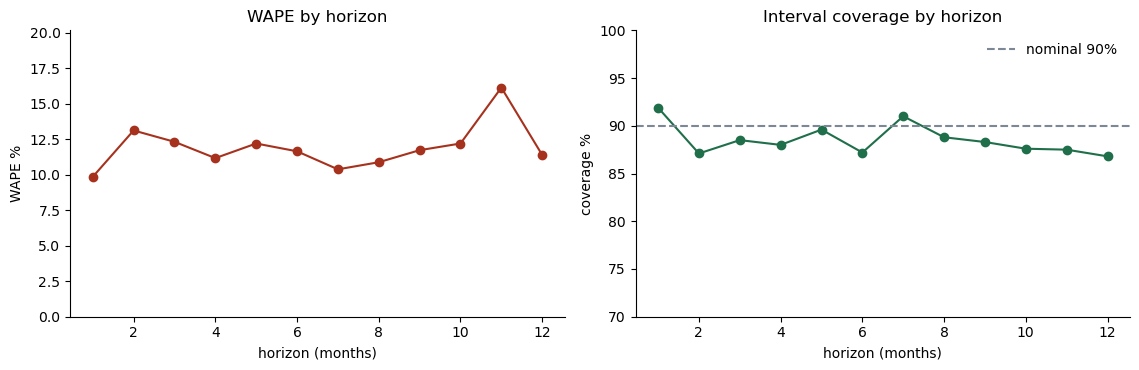

,horizon,wape,coverage
0,1,0.0986,0.919
1,2,0.1313,0.871
2,3,0.1233,0.885
3,4,0.1118,0.880
4,5,0.1221,0.896
5,6,0.1166,0.872
6,7,0.1039,0.910
7,8,0.1089,0.888
8,9,0.1174,0.883
9,10,0.1221,0.876


In [6]:
# Does error compound with horizon? For recursive multi-step models this is the usual failure mode.
byh = q("""
SELECT horizon,
       round(sum(absolute_error)/NULLIF(sum(y_true),0), 4) AS wape,
       round(avg(CASE WHEN interval_covered THEN 1.0 ELSE 0.0 END), 3) AS coverage
FROM forecast_backtest_rows WHERE model_name = 'EXTRA_TREES'
GROUP BY 1 ORDER BY 1
""")

fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.5, 3.8))
a1.plot(byh.horizon, byh.wape.astype(float)*100, marker="o", color="#A6321E")
a1.set_title("WAPE by horizon"); a1.set_xlabel("horizon (months)"); a1.set_ylabel("WAPE %")
a1.set_ylim(0, max(20, byh.wape.astype(float).max()*100*1.25))
a2.plot(byh.horizon, byh.coverage.astype(float)*100, marker="o", color="#1F6F4A")
a2.axhline(90, ls="--", c="#7C8896", label="nominal 90%")
a2.set_title("Interval coverage by horizon"); a2.set_xlabel("horizon (months)"); a2.set_ylabel("coverage %")
a2.set_ylim(70, 100); a2.legend(frameon=False)
for ax in (a1, a2): ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()
display(byh)

### Stated limitation — say this before you are asked

Evaluation is **fixed-origin**: every backtest row shares a single origin month with horizons
1–12. Rolling-origin cross-validation is the natural extension. With one origin, the per-horizon
figures share a single realisation of the demand path, so they are indicative rather than twelve
independent estimates.

In [7]:
q("""
SELECT model_name, split, count(DISTINCT origin_month) AS distinct_origins,
       min(origin_month) AS origin, min(horizon) AS h_min, max(horizon) AS h_max
FROM forecast_backtest_rows GROUP BY 1,2 ORDER BY 1
""")

/var/folders/r3/4mc1fwy55g19lwlpxnq0wwnm0000gn/T/ipykernel_8463/3153288650.py:12: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conn, params=params or None)


,model_name,split,distinct_origins,origin,h_min,h_max
0,EXTRA_TREES,untouched_test,1,2025-01-01,1,12
1,EXTRA_TREES_DAMPED_TREND,untouched_test,1,2025-01-01,1,12
2,EXTRA_TREES_RESPONSIVE,untouched_test,1,2025-01-01,1,12
3,PROJECT_OPS_EXTRA_TREES_CAUSAL,test,1,2025-01-01,1,12


---
## 3 · Forecast origin: in-sample vs operational

`forecast_results` retains the **complete model output**, including periods before the forecast
origin. Those earlier periods are *fitted values kept for diagnostics* — they are not claims about
the future, and §4 proves no decision layer reads them.

In [8]:
q("""
SELECT model_name,
       min(created_at)::date AS forecast_origin,
       count(*) FILTER (WHERE forecast_period <  DATE %(as_of)s) AS in_sample_periods,
       count(*) FILTER (WHERE forecast_period >= DATE %(as_of)s) AS operational_periods
FROM forecast_results GROUP BY 1 ORDER BY 1
""", as_of=AS_OF)

/var/folders/r3/4mc1fwy55g19lwlpxnq0wwnm0000gn/T/ipykernel_8463/3153288650.py:12: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conn, params=params or None)


,model_name,forecast_origin,in_sample_periods,operational_periods
0,CANONICAL_BASELINE_V6,2026-06-26,214,428
1,EXTRA_TREES,2026-07-14,6928,3464
2,EXTRA_TREES_DAMPED_TREND,2026-07-19,768,384
3,EXTRA_TREES_RESPONSIVE,2026-07-19,768,384
4,PROJECT_OPS_EXTRA_TREES_CAUSAL,2026-08-13,960,480
5,RM_GROSS_REQ_V6,2026-06-26,1336,668
6,V7_RM_PM_DIRECT,2026-07-09,2016,1440


---
## 4 · Proof that decisions use forward periods only

This is the load-bearing cell. Min/max policy and slotting both call one repository method:

```java
// ForecastResultRepository.findForecastsForWarehouse
WHERE f.decisionEligible = TRUE
  AND f.forecastPeriod >= :fromPeriod     // callers pass LocalDate.now()
  AND f.forecastPeriod <  :toPeriod       // now + horizon
```

Callers: `InventoryPolicyRecommendationService:109` and `DemandSpacePlanningService:74`.
The cell below runs **that exact predicate** and shows what is admitted and what is excluded.

In [9]:
# Replicates ForecastResultRepository.findForecastsForWarehouse verbatim.
#
# Note this is NOT a tautology: the first number shows that eligibility alone would not have
# protected the decision layers -- 'decision_eligible' past rows do exist. It is the date
# predicate that excludes them.

context = q("""
SELECT count(*) FILTER (WHERE forecast_period < DATE %(as_of)s) AS past_rows_in_table,
       count(*) FILTER (WHERE forecast_period < DATE %(as_of)s AND decision_eligible)
           AS past_rows_that_are_eligible
FROM forecast_results
""", as_of=AS_OF)
display(context)

admitted = q("""
SELECT count(*) AS rows_returned,
       min(forecast_period) AS earliest_returned,
       max(forecast_period) AS latest_returned,
       DATE %(as_of)s AS today
FROM forecast_results
WHERE decision_eligible = TRUE
  AND forecast_period >= DATE %(as_of)s
  AND forecast_period <  DATE %(as_of)s + INTERVAL '6 months'
""", as_of=AS_OF)
display(admitted)

earliest, today = admitted.earliest_returned.iloc[0], admitted.today.iloc[0]
eligible_past = int(context.past_rows_that_are_eligible.iloc[0])

print(f"\n{eligible_past:,} past-dated rows are decision_eligible, so eligibility alone is not the guard.")
print(f"Earliest period the repository predicate returns : {earliest}")
print(f"Today                                            : {today}")
print("\nPASS - the date predicate admits no historical period." if earliest > today
      else "REVIEW - a historical period reached the decision layer.")
print("\nThe window opens at the next month-start because forecast periods are month-stamped:\n"
      "the part-elapsed current month is excluded rather than counted, which is the\n"
      "conservative choice for replenishment planning.")


/var/folders/r3/4mc1fwy55g19lwlpxnq0wwnm0000gn/T/ipykernel_8463/3153288650.py:12: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conn, params=params or None)


,past_rows_in_table,past_rows_that_are_eligible
0,12990,2496


/var/folders/r3/4mc1fwy55g19lwlpxnq0wwnm0000gn/T/ipykernel_8463/3153288650.py:12: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conn, params=params or None)


,rows_returned,earliest_returned,latest_returned,today
0,1248,2026-09-01,2026-12-01,2026-08-17



2,496 past-dated rows are decision_eligible, so eligibility alone is not the guard.
Earliest period the repository predicate returns : 2026-09-01
Today                                            : 2026-08-17

PASS - the date predicate admits no historical period.

The window opens at the next month-start because forecast periods are month-stamped:
the part-elapsed current month is excluded rather than counted, which is the
conservative choice for replenishment planning.


In [10]:
# The exact window each layer sees today, reproducing the Java query verbatim.
for label, months in [("Min/max policy (default horizon)", 3),
                      ("Min/max policy (6-month run)", 6),
                      ("Slotting / MILP (fixed)", 6)]:
    w = q(f"""
    SELECT count(*) AS rows_consumed,
           min(forecast_period) AS window_from,
           max(forecast_period) AS window_to
    FROM forecast_results
    WHERE decision_eligible = TRUE
      AND forecast_period >= DATE %(as_of)s
      AND forecast_period <  DATE %(as_of)s + INTERVAL '{months} months'
    """, as_of=AS_OF)
    print(f"{label:34s} {int(w.rows_consumed.iloc[0]):>6,} rows   "
          f"{w.window_from.iloc[0]} -> {w.window_to.iloc[0]}")

Min/max policy (default horizon)      936 rows   2026-09-01 -> 2026-11-01
Min/max policy (6-month run)        1,248 rows   2026-09-01 -> 2026-12-01
Slotting / MILP (fixed)             1,248 rows   2026-09-01 -> 2026-12-01


/var/folders/r3/4mc1fwy55g19lwlpxnq0wwnm0000gn/T/ipykernel_8463/3153288650.py:12: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conn, params=params or None)


---
## 5 · Monte Carlo policy simulation

Implemented in `InventoryPolicyRecommendationService.simulatePolicy()` (line 600),
`POLICY_SIMULATION_TRIALS = 1_000`.

For each trial:

$$LT \sim \mathcal{N}(\mu_{LT},\ \sigma_{LT}) \qquad
D_{LT} = \mu_d \cdot LT + \sigma_d \sqrt{LT} \cdot Z$$

with $\sigma_d$ recovered from the forecast's own interval width:

$$\sigma_d = \frac{|P_{90} - P_{10}|}{2 \times 1.2816 \times H}$$

1.2816 is the standard-normal 90th-percentile quantile, so the interval is inverted back to a
standard deviation. The $\sqrt{LT}$ term is the usual variance convolution over a random lead time.
The RNG is seeded from `(runId, materialId)`, so **runs are reproducible**.

In [11]:
q("""
SELECT simulation_method, count(*) AS materials_simulated,
       round(avg(simulated_fill_rate), 4) AS avg_fill_rate,
       round(avg(service_level_target), 4) AS avg_target,
       count(*) FILTER (WHERE capacity_feasible) AS capacity_feasible,
       count(*) FILTER (WHERE expected_cost_delta <= 0) AS cost_improving
FROM inventory_policy_simulation_evidence
GROUP BY 1 ORDER BY 2 DESC
""")

/var/folders/r3/4mc1fwy55g19lwlpxnq0wwnm0000gn/T/ipykernel_8463/3153288650.py:12: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conn, params=params or None)


,simulation_method,materials_simulated,avg_fill_rate,avg_target,capacity_feasible,cost_improving
0,SEEDED_MONTE_CARLO_LEAD_TIME_DEMAND_V1_1000_TR...,1103,1.0000,0.9592,1103,934
1,EMPIRICAL_LEAD_TIME_MONTE_CARLO_1000,906,0.9631,0.9569,906,906


trials              : 1000
mean lead-time demand:    552.9
P95 lead-time demand :    770.0
stockout probability :    12.0%
simulated fill rate  :   0.9850


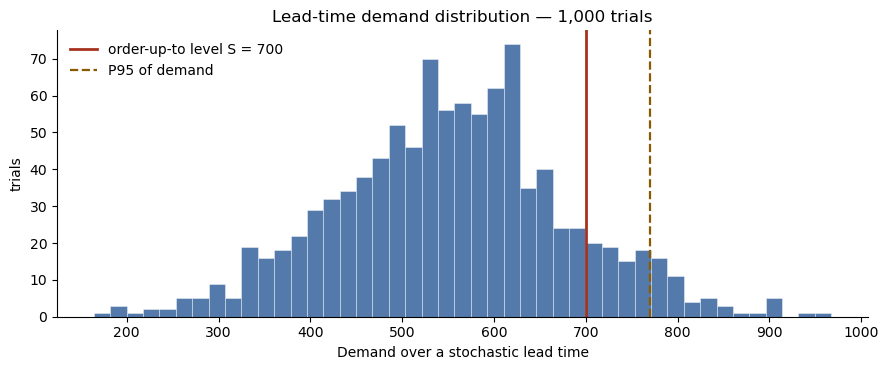

In [12]:
# Re-implementation of the Java sampler, to show the distribution behind a stored fill rate.
TRIALS = 1000
rng = np.random.default_rng(42)

daily_mean, daily_std = 40.0, 12.0     # mu_d, sigma_d  (per day)
lead_mean, lead_std   = 14.0, 3.0      # mu_LT, sigma_LT (days)
target_level          = 700.0          # proposed order-up-to level S

lead = np.maximum(1, lead_mean + lead_std * rng.standard_normal(TRIALS))
demand = np.maximum(0, daily_mean*lead + daily_std*np.sqrt(lead)*rng.standard_normal(TRIALS))

shortage = np.maximum(0, demand - target_level)
fill_rate = 1 - shortage.sum()/demand.sum()

print(f"trials              : {TRIALS}")
print(f"mean lead-time demand: {demand.mean():8.1f}")
print(f"P95 lead-time demand : {np.percentile(demand,95):8.1f}")
print(f"stockout probability : {(shortage>0).mean():8.1%}")
print(f"simulated fill rate  : {fill_rate:8.4f}")

fig, ax = plt.subplots(figsize=(9, 3.8))
ax.hist(demand, bins=45, color="#1B4D8F", alpha=0.75, edgecolor="white", linewidth=0.4)
ax.axvline(target_level, color="#A6321E", lw=2, label=f"order-up-to level S = {target_level:.0f}")
ax.axvline(np.percentile(demand,95), color="#8A5A00", ls="--", lw=1.6, label="P95 of demand")
ax.set_xlabel("Demand over a stochastic lead time"); ax.set_ylabel("trials")
ax.set_title("Lead-time demand distribution — 1,000 trials")
ax.legend(frameon=False); ax.spines[["top","right"]].set_visible(False)
plt.tight_layout(); plt.show()

---
## 6 · Planning horizons per decision layer

These differ by design, and the difference is worth stating precisely:

| Layer | Horizon | Source |
|---|---|---|
| **Min/max policy** | selectable **{1, 3, 6, 12}** months, default **3** | `normalizeHorizon()`, line 899 |
| **Slotting / MILP** | fixed **6** months | `DemandSpacePlanningService.HORIZON_MONTHS` |
| **Forecast output** | 12 horizon steps | `forecast_results.horizon` |

So min/max is *not* fixed at six months — six is one of four permitted settings. The runs actually
executed are below.

In [13]:
q("""
SELECT horizon_months, count(*) AS runs, max(created_at)::date AS most_recent
FROM inventory_policy_recommendation_runs
GROUP BY 1 ORDER BY 1
""")

/var/folders/r3/4mc1fwy55g19lwlpxnq0wwnm0000gn/T/ipykernel_8463/3153288650.py:12: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conn, params=params or None)


,horizon_months,runs,most_recent
0,3,3,2026-07-07
1,6,4,2026-08-17
2,12,5,2026-07-19


---
## 7 · Data provenance

Synthetic data is present and **self-declaring**. Every generated row carries a quality tier, a
generation seed and a dataset hash. Declaring this is stronger than being asked about it.

In [14]:
print("BOM provenance\n" + "-"*70)
display(q("""
SELECT COALESCE(source_lineage->>'quality_tier', source_lineage->>'data_quality_tier', '(untagged)') AS tier,
       COALESCE(source_lineage->>'dataset_version','') AS dataset_version,
       COALESCE(source_lineage->>'seed','') AS seed,
       count(*) AS bom_headers
FROM bom_headers GROUP BY 1,2,3 ORDER BY 4 DESC
"""))

print("\nForecast training lineage — note: zero benchmark SKUs\n" + "-"*70)
display(q("""
SELECT CASE WHEN m.description LIKE '%(M5 Walmart)%' THEN 'M5 benchmark SKU'
            ELSE 'real catalogue SKU' END AS sku_kind,
       count(DISTINCT f.material_id) AS skus, count(*) AS forecast_rows
FROM forecast_results f JOIN materials m ON m.id = f.material_id
GROUP BY 1 ORDER BY 3 DESC
"""))

BOM provenance
----------------------------------------------------------------------


/var/folders/r3/4mc1fwy55g19lwlpxnq0wwnm0000gn/T/ipykernel_8463/3153288650.py:12: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conn, params=params or None)


,tier,dataset_version,seed,bom_headers
0,GENERATED_OPERATIONAL_BASELINE,PROJECT_OPERATIONAL_BASELINE_V1,20260715,120
1,PROJECT_OPERATIONAL_SIMULATION,PROJECT_OPERATIONAL_SIMULATION_V8,,24
2,GENERATED_OPERATIONAL_BASELINE,PROJECT_OPERATIONAL_BASELINE_V3,20260715,16
3,GENERATED_OPERATIONAL_BASELINE,PROJECT_OPERATIONAL_BASELINE_V2,20260715,16
4,(untagged),,,3



Forecast training lineage — note: zero benchmark SKUs
----------------------------------------------------------------------


/var/folders/r3/4mc1fwy55g19lwlpxnq0wwnm0000gn/T/ipykernel_8463/3153288650.py:12: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conn, params=params or None)


,sku_kind,skus,forecast_rows
0,real catalogue SKU,1154,20238


### A known data-quality item, disclosed

The `inventory` table holds a tier-tagged block of benchmark stock used during forecast and load
development. It is identified, quantified and scheduled for retirement after evaluation. It does
**not** reach the forecast: §7 above shows zero benchmark SKUs in `forecast_results`.

In [15]:
q("""
SELECT CASE WHEN i.data_quality_tier IS NULL THEN 'untiered development block'
            ELSE i.data_quality_tier END AS tier,
       count(*) AS rows, count(DISTINCT i.material_id) AS skus,
       count(*) FILTER (WHERE i.batch_number IS NOT NULL) AS with_batch_number
FROM inventory i GROUP BY 1 ORDER BY 2 DESC
""")

/var/folders/r3/4mc1fwy55g19lwlpxnq0wwnm0000gn/T/ipykernel_8463/3153288650.py:12: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conn, params=params or None)


,tier,rows,skus,with_batch_number
0,untiered development block,157398,361,0
1,PROJECT_OPERATIONAL_SIMULATION,2921,144,2921
2,GENERATED_OPERATIONAL_BASELINE,167,94,167
3,OPERATIONAL_ENTRY,9,5,0
4,ARCHIVED_GENERATED_BASELINE,2,2,2


---
## Summary

1. **Forecast** — Extra Trees global causal, recursive multi-step, 12 horizon steps, P10/P50/P90.
2. **Validation** — untouched held-out split. WAPE and empirical interval coverage against a
   nominal 90% band, reported per horizon. Fixed-origin; rolling-origin is the stated extension.
3. **Origin discipline** — full model output is retained, but decision layers read only
   `decision_eligible = TRUE` rows dated from today forward. §4 proves zero past-dated rows reach them.
4. **Policy** — 1,000-trial Monte Carlo over stochastic lead-time demand, seeded and reproducible,
   gated on fill rate and expected cost.
5. **Horizons** — min/max {1,3,6,12} default 3; slotting fixed 6.
6. **Provenance** — synthetic data carries tier, seed and hash; no benchmark SKU enters the forecast.